# US Accidents Severity Prediction — Data Quality, EDA, Leakage & Outlier Analysis

---
**File:** `02_eda.ipynb`
**Purpose:** Stage 3 — Data Understanding and Exploratory Data Analysis
**Input:** `../data/US_Accidents_1M.csv` (output of `01_sampling.ipynb`)
**Outputs:** CSV reports in `../outputs/reports/`, charts in `../outputs/figures/`

**Quick navigation:**
| Section | What it covers |
|---|---|
| 1 | Data quality: shape, types, missing values, duplicates, constants, target distribution |
| 2 | Leakage assessment: which columns are safe to use at prediction time |
| 3 | Outlier analysis: IQR-based bounds and counts |
| 4 | Visualizations: severity, missingness, temporal, weather, state patterns |
---

## A. Data Quality Analysis
Full-dataset profiling: dimensions, column types, missing values, duplicates, constant columns, target distribution, and numeric summary.

In [28]:
import os
import pandas as pd

DATA_FILE = "../data/US_Accidents_1M.csv"
OUTPUT_DIR = "../outputs/reports"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading dataset...")
df = pd.read_csv(DATA_FILE)
print("Dataset loaded successfully.")

Loading dataset...
Dataset loaded successfully.


### A.1 Dataset dimensions

In [29]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 999,592
Columns : 46


### A.2 Column information

In [30]:
# Builds a full column-by-column profile: data type, unique value count, and missing value stats.
# Saved to column_profile.csv for reference in the report.
column_info = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Unique_Values": [df[column].nunique(dropna=True) for column in df.columns],
    "Missing_Values": [df[column].isna().sum() for column in df.columns],
    "Missing_Percentage": [df[column].isna().mean() * 100 for column in df.columns]
})

print(column_info.to_string(index=False))
column_info.to_csv(f"{OUTPUT_DIR}/column_profile.csv", index=False)

               Column Data_Type  Unique_Values  Missing_Values  Missing_Percentage
                   ID       str         999592               0            0.000000
               Source       str              3               0            0.000000
             Severity     int64              4               0            0.000000
           Start_Time       str         951934               0            0.000000
             End_Time       str         975610               0            0.000000
            Start_Lat   float64         637710               0            0.000000
            Start_Lng   float64         641580               0            0.000000
              End_Lat   float64         389775          440420           44.059976
              End_Lng   float64         392796          440420           44.059976
         Distance(mi)   float64          13052               0            0.000000
          Description       str         746436               0            0.000000
    

### A.3 Duplicate records

In [31]:
# 1.2 Check for exact duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

duplicate_result = pd.DataFrame({"Metric": ["Duplicate Rows"], "Count": [duplicate_count]})
duplicate_result.to_csv(f"{OUTPUT_DIR}/duplicate_analysis.csv", index=False)

Duplicate rows: 0


### A.4 Identify constant / near-constant columns
Columns with only one unique value carry no predictive information and are candidates for removal in preprocessing.

In [32]:
constant_columns = [column for column in df.columns if df[column].nunique(dropna=False) <= 1]

if constant_columns:
    print("Constant columns:")
    for column in constant_columns:
        print(f"- {column}")
else:
    print("No constant columns found.")

constant_result = pd.DataFrame({"Constant_Column": constant_columns})
constant_result.to_csv(f"{OUTPUT_DIR}/constant_columns.csv", index=False)

Constant columns:
- Country
- Turning_Loop


### A.5 Target variable (Severity) distribution
Confirms the severe class imbalance that will drive SMOTE/class-weighting decisions later.

In [33]:
severity_counts = df["Severity"].value_counts().sort_index()
severity_percentage = df["Severity"].value_counts(normalize=True).sort_index() * 100

severity_summary = pd.DataFrame({
    "Severity": severity_counts.index,
    "Count": severity_counts.values,
    "Percentage": severity_percentage.values
})

print(severity_summary.to_string(index=False))
severity_summary.to_csv(f"{OUTPUT_DIR}/severity_distribution.csv", index=False)

 Severity  Count  Percentage
        1   8612    0.861552
        2 796136   79.646096
        3 168682   16.875085
        4  26162    2.617268


### A.6 Descriptive statistics for numeric columns

In [34]:
numeric_summary = df.describe().T
numeric_summary.to_csv(f"{OUTPUT_DIR}/numeric_summary.csv")
print(numeric_summary.to_string())

                      count       mean        std         min         25%        50%        75%         max
Severity           999592.0   2.212481   0.486733    1.000000    2.000000   2.000000   2.000000    4.000000
Start_Lat          999592.0  36.196873   5.076672   24.566999   33.399203  35.820965  40.081799   49.000260
Start_Lng          999592.0 -94.719178  17.397435 -124.548074 -117.223556 -87.785899 -80.352691  -67.606864
End_Lat            559172.0  36.259736   5.272316   24.569978   33.462150  36.175894  40.171208   48.999157
End_Lng            559172.0 -95.739994  18.108380 -124.545748 -117.752104 -88.032315 -80.247521  -67.606864
Distance(mi)       999592.0   0.563092   1.756490    0.000000    0.000000   0.029000   0.465000  194.729996
Temperature(F)     978269.0  61.673274  19.022551  -89.000000   49.000000  64.000000  76.000000  189.000000
Wind_Chill(F)      740375.0  58.239888  22.395904  -89.000000   43.000000  62.000000  75.000000  189.000000
Humidity(%)        976971.0 

### A.7 Memory usage

In [35]:
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory usage: {memory_mb:.2f} MB")
print(f"\nReports saved to: {OUTPUT_DIR}/")

Memory usage: 1254.12 MB

Reports saved to: ../outputs/reports/


## B. Leakage / Prediction-Time Availability Assessment
Column-by-column assessment of whether each feature would realistically be available at the moment a prediction needs to be made, or whether it risks leaking post-event information.

In [36]:
#Load sample for assessment
INPUT_FILE = "../data/US_Accidents_1M.csv"
LEAKAGE_OUTPUT = "../outputs/reports/leakage_analysis.csv"
os.makedirs("../outputs/reports", exist_ok=True)

df_sample = pd.read_csv(INPUT_FILE, nrows=1000)
print(f"Loaded sample for leakage assessment: {df_sample.shape}")

Loaded sample for leakage assessment: (1000, 46)


### B.1 Define the assessment for every column
Categories: Available | Potential leakage | Exclude | Target | Investigate

In [37]:
assessment = {
    "ID": {"availability": "Exclude", "reason": "Unique record identifier; does not represent accident characteristics."},
    "Source": {"availability": "Investigate", "reason": "May reflect the data collection source rather than the accident itself."},
    "Severity": {"availability": "Target", "reason": "Prediction target; must not be used as an input feature."},
    "Start_Time": {"availability": "Available", "reason": "Represents the accident start/reporting time and can support temporal features."},
    "End_Time": {"availability": "Potential leakage", "reason": "Event end time may only become known after the incident progresses."},
    "Start_Lat": {"availability": "Available", "reason": "Starting geographic location can reasonably be available when the incident is reported."},
    "Start_Lng": {"availability": "Available", "reason": "Starting geographic location can reasonably be available when the incident is reported."},
    "End_Lat": {"availability": "Potential leakage", "reason": "Ending location may be determined after the event and is also substantially missing."},
    "End_Lng": {"availability": "Potential leakage", "reason": "Ending location may be determined after the event and is also substantially missing."},
    "Distance(mi)": {"availability": "Investigate", "reason": "May describe the spatial extent of the event and could contain post-event information."},
    "Description": {"availability": "Investigate", "reason": "Free-text information may contain details added after initial reporting."},
    "Street": {"availability": "Available", "reason": "Road/street information can potentially be known at incident reporting."},
    "City": {"availability": "Available", "reason": "Location information can potentially be known at incident reporting."},
    "County": {"availability": "Available", "reason": "Geographical information associated with the incident location."},
    "State": {"availability": "Available", "reason": "Geographical information associated with the incident location."},
    "Zipcode": {"availability": "Available", "reason": "Location information can potentially be known at incident reporting."},
    "Country": {"availability": "Exclude", "reason": "Constant value in the working dataset."},
    "Timezone": {"availability": "Available", "reason": "Can be derived from or associated with the incident location."},
    "Airport_Code": {"availability": "Investigate", "reason": "Related to nearby weather reporting infrastructure rather than directly to the accident."},
    "Weather_Timestamp": {"availability": "Investigate", "reason": "Must ensure the weather observation does not occur after the prediction time."},
    "Temperature(F)": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Wind_Chill(F)": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Humidity(%)": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Pressure(in)": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Visibility(mi)": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Wind_Direction": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Wind_Speed(mph)": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Precipitation(in)": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations, but missingness is substantial."},
    "Weather_Condition": {"availability": "Investigate", "reason": "Potentially available from contemporaneous weather observations."},
    "Amenity": {"availability": "Available", "reason": "Road/environment context that can potentially be known at the incident location."},
    "Bump": {"availability": "Available", "reason": "Road/environment context that can potentially be known at the incident location."},
    "Crossing": {"availability": "Available", "reason": "Road intersection/context information."},
    "Give_Way": {"availability": "Available", "reason": "Road traffic-control context."},
    "Junction": {"availability": "Available", "reason": "Road intersection/context information."},
    "No_Exit": {"availability": "Available", "reason": "Road/environment context."},
    "Railway": {"availability": "Available", "reason": "Road/environment context."},
    "Roundabout": {"availability": "Available", "reason": "Road/environment context."},
    "Station": {"availability": "Available", "reason": "Road/environment context."},
    "Stop": {"availability": "Available", "reason": "Traffic-control context."},
    "Traffic_Calming": {"availability": "Available", "reason": "Road/environment context."},
    "Traffic_Signal": {"availability": "Available", "reason": "Traffic-control context."},
    "Turning_Loop": {"availability": "Exclude", "reason": "Constant value in the working dataset."},
    "Sunrise_Sunset": {"availability": "Available", "reason": "Can be derived from accident time and location."},
    "Civil_Twilight": {"availability": "Available", "reason": "Can be derived from accident time and location."},
    "Nautical_Twilight": {"availability": "Available", "reason": "Can be derived from accident time and location."},
    "Astronomical_Twilight": {"availability": "Available", "reason": "Can be derived from accident time and location."}
}

### B.2 Build and save the assessment report

In [38]:
rows = []

for feature in df_sample.columns:
    if feature in assessment:
        rows.append({
            "Feature": feature,
            "Availability_Assessment": assessment[feature]["availability"],
            "Reason": assessment[feature]["reason"]
        })
    else:
        rows.append({"Feature": feature, "Availability_Assessment": "Needs review", "Reason": "No assessment defined."})

leakage_df = pd.DataFrame(rows)
leakage_df.to_csv(LEAKAGE_OUTPUT, index=False)

print("\nPrediction-time availability assessment:")
print(leakage_df[["Feature", "Availability_Assessment"]].to_string(index=False))
print("\nAssessment counts:")
print(leakage_df["Availability_Assessment"].value_counts())
print(f"\nSaved report to: {LEAKAGE_OUTPUT}")


Prediction-time availability assessment:
              Feature Availability_Assessment
                   ID                 Exclude
               Source             Investigate
             Severity                  Target
           Start_Time               Available
             End_Time       Potential leakage
            Start_Lat               Available
            Start_Lng               Available
              End_Lat       Potential leakage
              End_Lng       Potential leakage
         Distance(mi)             Investigate
          Description             Investigate
               Street               Available
                 City               Available
               County               Available
                State               Available
              Zipcode               Available
              Country                 Exclude
             Timezone               Available
         Airport_Code             Investigate
    Weather_Timestamp             Inve

## C. Outlier Analysis (IQR-based)
Quantifying outliers in numeric weather/distance variables using the standard 1.5×IQR rule.

In [39]:
#Load dataset
import numpy as np

INPUT_FILE = "../data/US_Accidents_1M.csv"
REPORT_DIR = "../outputs/reports"
os.makedirs(REPORT_DIR, exist_ok=True)

print("Loading dataset...")
df = pd.read_csv(INPUT_FILE)
print(f"Dataset shape: {df.shape}")

Loading dataset...
Dataset shape: (999592, 46)


### C.1 Compute IQR bounds and outlier counts per feature
Uses the standard 1.5×IQR rule. Outlier_Percentage tells us how much of each column falls outside the "normal" range.

In [40]:
features = [
    "Distance(mi)", "Temperature(F)", "Wind_Chill(F)", "Humidity(%)",
    "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"
]

results = []

for feature in features:
    series = df[feature].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]

    results.append({
        "Feature": feature, "Q1": q1, "Median": series.median(), "Q3": q3, "IQR": iqr,
        "Lower_Bound": lower_bound, "Upper_Bound": upper_bound,
        "Minimum": series.min(), "Maximum": series.max(),
        "Outlier_Count": len(outliers), "Outlier_Percentage": len(outliers) / len(series) * 100
    })

outlier_report = pd.DataFrame(results)
outlier_report = outlier_report.round(4)

output_file = f"{REPORT_DIR}/outlier_analysis.csv"
outlier_report.to_csv(output_file, index=False)

print("\nIQR-based outlier analysis:")
print(outlier_report.to_string(index=False))
print(f"\nSaved report to: {output_file}")


IQR-based outlier analysis:
          Feature    Q1  Median     Q3    IQR  Lower_Bound  Upper_Bound  Minimum  Maximum  Outlier_Count  Outlier_Percentage
     Distance(mi)  0.00   0.029  0.465  0.465      -0.6975       1.1625     0.00   194.73         124418             12.4469
   Temperature(F) 49.00  64.000 76.000 27.000       8.5000     116.5000   -89.00   189.00           6540              0.6685
    Wind_Chill(F) 43.00  62.000 75.000 32.000      -5.0000     123.0000   -89.00   189.00           5712              0.7715
      Humidity(%) 48.00  67.000 84.000 36.000      -6.0000     138.0000     1.00   100.00              0              0.0000
     Pressure(in) 29.37  29.860 30.030  0.660      28.3800      31.0200     0.12    58.63          56989              5.8080
   Visibility(mi) 10.00  10.000 10.000  0.000      10.0000      10.0000     0.00   120.00         191261             19.5852
  Wind_Speed(mph)  4.60   7.000 10.400  5.800      -4.1000      19.1000     0.00   822.80       

### C.2 Sanity-check extreme min/max values
Cross-checks IQR-flagged outliers against physically implausible values (e.g., wind speed >900mph).

In [41]:
print("Extreme observations:")

for feature in features:
    series = df[feature]
    print(f"{feature}: min={series.min()}, max={series.max()}, median={series.median()}")

Extreme observations:
Distance(mi): min=0.0, max=194.72999572753903, median=0.029
Temperature(F): min=-89.0, max=189.0, median=64.0
Wind_Chill(F): min=-89.0, max=189.0, median=62.0
Humidity(%): min=1.0, max=100.0, median=67.0
Pressure(in): min=0.12, max=58.63, median=29.86
Visibility(mi): min=0.0, max=120.0, median=10.0
Wind_Speed(mph): min=0.0, max=822.8, median=7.0
Precipitation(in): min=0.0, max=36.47, median=0.0


## D. EDA Visualizations
Severity distribution, missing values, temporal patterns, missingness-by-severity, weather-vs-severity, and state-level patterns.

In [42]:
#Load dataset and prepare time features
import matplotlib.pyplot as plt

INPUT_FILE = "../data/US_Accidents_1M.csv"
FIGURE_DIR = "../outputs/figures"
REPORT_DIR = "../outputs/reports"
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Loading dataset...")
df = pd.read_csv(INPUT_FILE)
print(f"Dataset shape: {df.shape}")

df["Start_Time"] = pd.to_datetime(
    df["Start_Time"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
)
print("Unparsed Start_Time:", df["Start_Time"].isna().sum())
df["Year"] = df["Start_Time"].dt.year
df["Month"] = df["Start_Time"].dt.month
df["Hour"] = df["Start_Time"].dt.hour
df["Day_of_Week"] = df["Start_Time"].dt.day_name()

Loading dataset...
Dataset shape: (999592, 46)
Unparsed Start_Time: 0


### D.1 Severity distribution (chart)

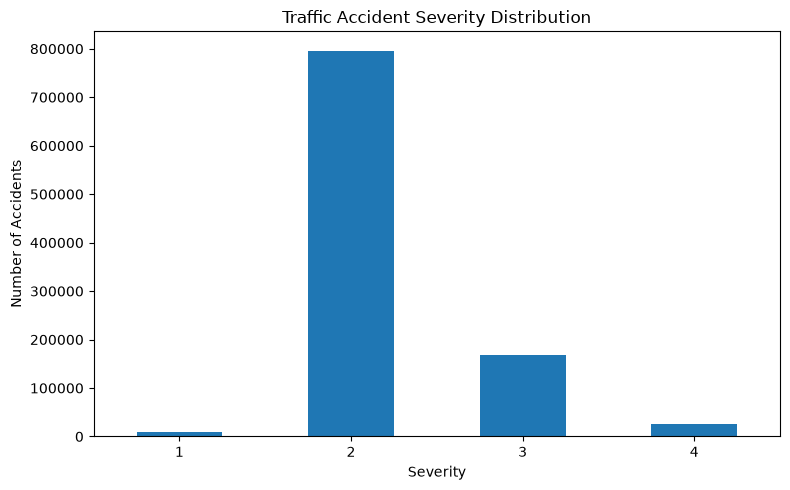

In [43]:
severity_counts = df["Severity"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
severity_counts.plot(kind="bar")
plt.title("Traffic Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/01_severity_distribution.png", dpi=300)
plt.show()

severity_percent = (severity_counts / severity_counts.sum() * 100).round(2)
severity_report = pd.DataFrame({
    "Severity": severity_counts.index,
    "Count": severity_counts.values,
    "Percentage": severity_percent.values
})
severity_report.to_csv(f"{REPORT_DIR}/severity_distribution.csv", index=False)

### D.2 Missing values by column (chart)

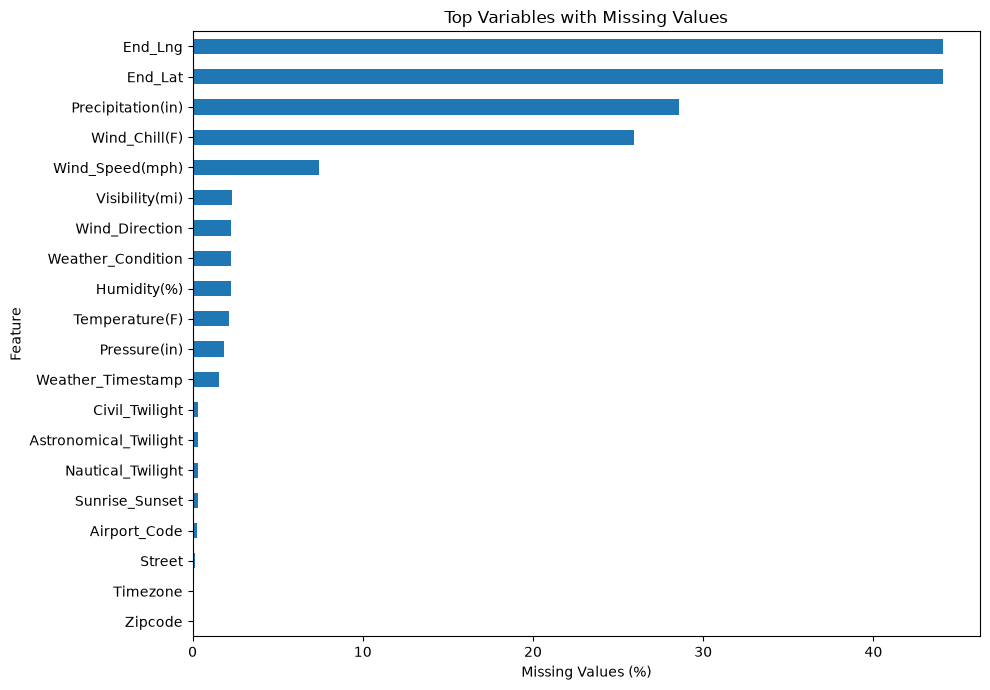

In [44]:
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({"Missing_Count": missing, "Missing_Percentage": missing_percent})
missing_report = missing_report[missing_report["Missing_Count"] > 0].sort_values("Missing_Percentage", ascending=False)
missing_report.to_csv(f"{REPORT_DIR}/missing_values.csv")

plt.figure(figsize=(10, 7))
missing_plot = missing_report.head(20)
missing_plot["Missing_Percentage"].sort_values().plot(kind="barh")
plt.title("Top Variables with Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/02_missing_values.png", dpi=300)
plt.show()

### D.3 Accidents by year, split by severity — raw counts

<Figure size 1000x600 with 0 Axes>

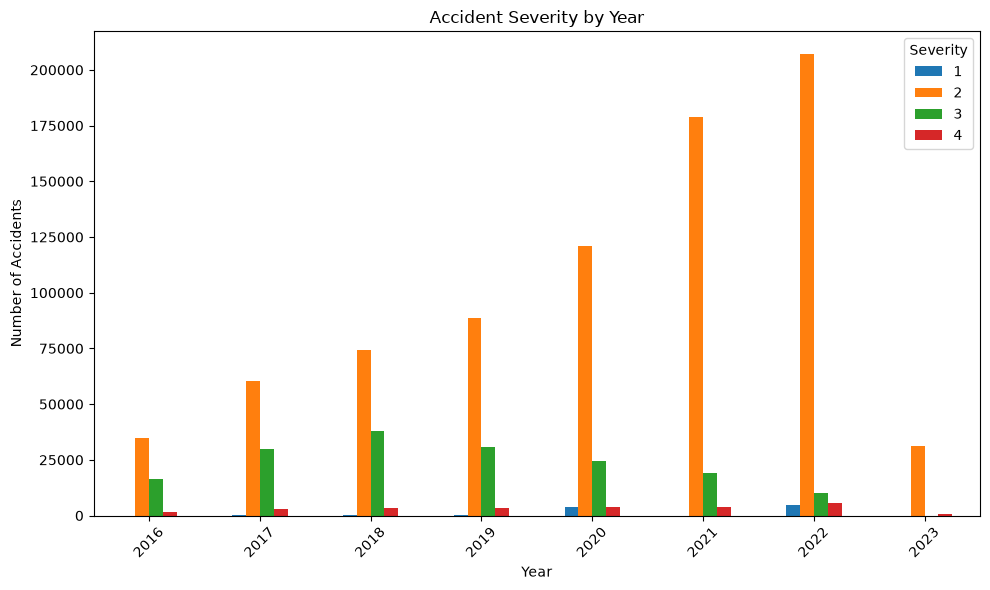

In [45]:
year_severity = pd.crosstab(df["Year"], df["Severity"])
year_severity.to_csv(f"{REPORT_DIR}/year_severity_counts.csv")

plt.figure(figsize=(10, 6))
year_severity.plot(kind="bar", figsize=(10, 6))
plt.title("Accident Severity by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/03_year_severity_counts.png", dpi=300)
plt.show()

### D.4 Severity proportions within each year (%)
Normalizes by year to check whether the severity mix has shifted over time, independent of overall volume growth.

<Figure size 1000x600 with 0 Axes>

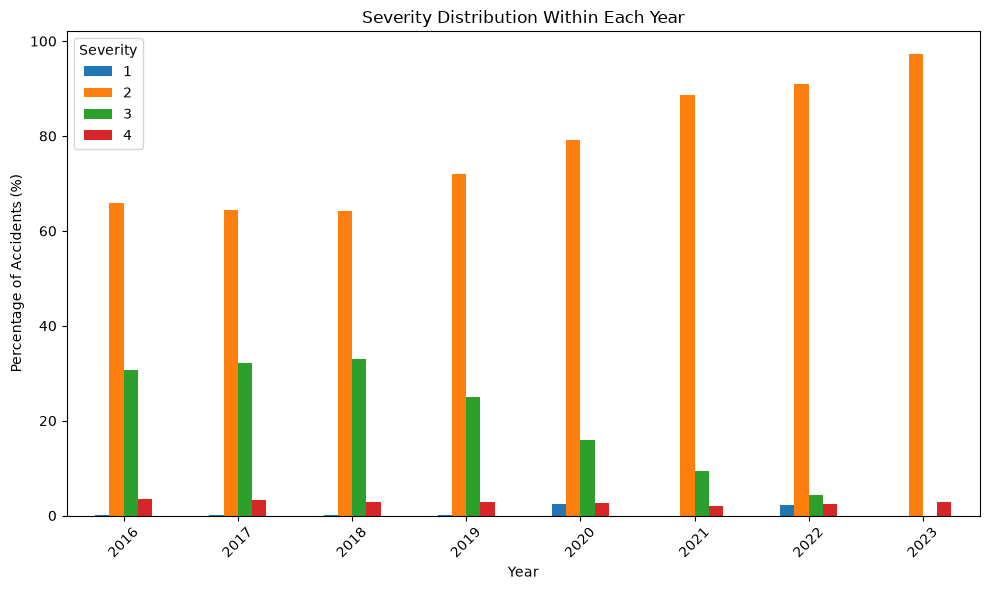

In [46]:
year_severity_percent = (pd.crosstab(df["Year"], df["Severity"], normalize="index") * 100).round(2)
year_severity_percent.to_csv(f"{REPORT_DIR}/year_severity_percentages.csv")

plt.figure(figsize=(10, 6))
year_severity_percent.plot(kind="bar", figsize=(10, 6))
plt.title("Severity Distribution Within Each Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Accidents (%)")
plt.xticks(rotation=45)
plt.legend(title="Severity")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/04_year_severity_percentages.png", dpi=300)
plt.show()

### D.5 Missingness by severity class
If certain severity classes have much higher missingness in a column, that suggests non-random missingness tied to how incidents are logged.

<Figure size 1200x700 with 0 Axes>

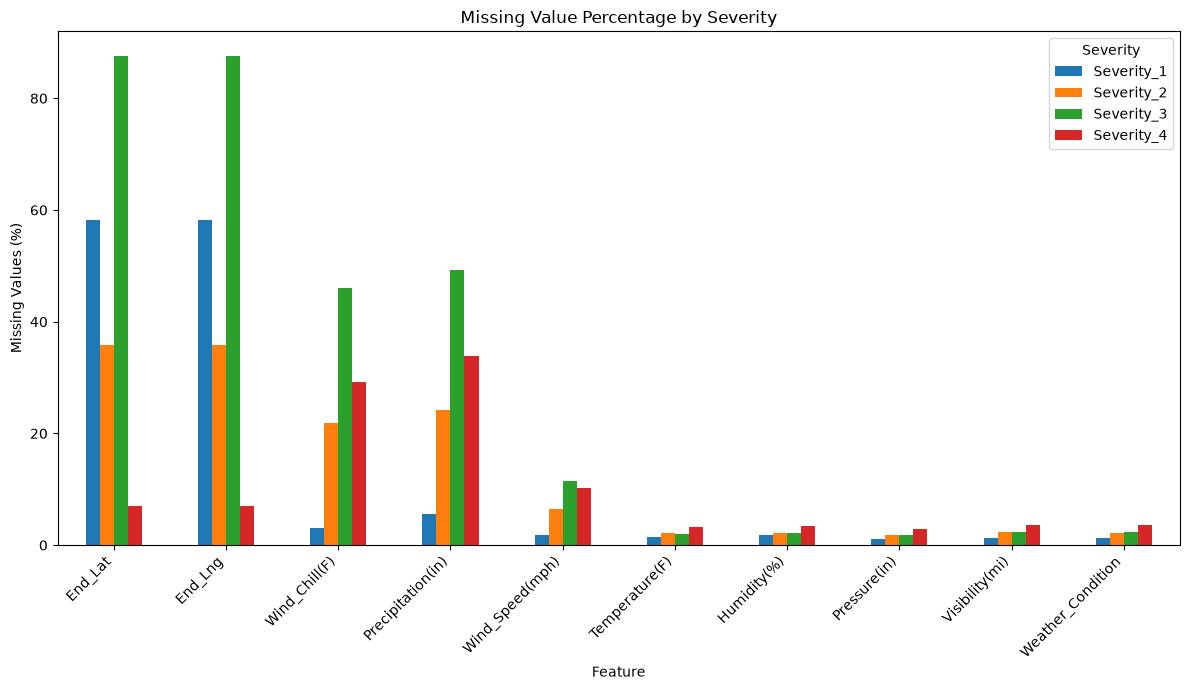

In [47]:
important_missing_features = [
    "End_Lat", "End_Lng", "Wind_Chill(F)", "Precipitation(in)", "Wind_Speed(mph)",
    "Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Weather_Condition"
]

missing_by_severity = {}

for feature in important_missing_features:
    if feature in df.columns:
        result = df.groupby("Severity")[feature].apply(lambda x: x.isna().mean() * 100)
        missing_by_severity[feature] = result

missing_severity_df = pd.DataFrame(missing_by_severity).T
missing_severity_df.columns = [f"Severity_{int(col)}" for col in missing_severity_df.columns]
missing_severity_df = missing_severity_df.round(2)
missing_severity_df.to_csv(f"{REPORT_DIR}/missingness_by_severity.csv")

plt.figure(figsize=(12, 7))
missing_severity_df.plot(kind="bar", figsize=(12, 7))
plt.title("Missing Value Percentage by Severity")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Severity")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/05_missingness_by_severity.png", dpi=300)
plt.show()

### D.6 Weather variables vs. severity
Boxplots to visually check whether temperature, humidity, visibility, wind speed, or precipitation differ meaningfully across severity classes.

<Figure size 900x600 with 0 Axes>

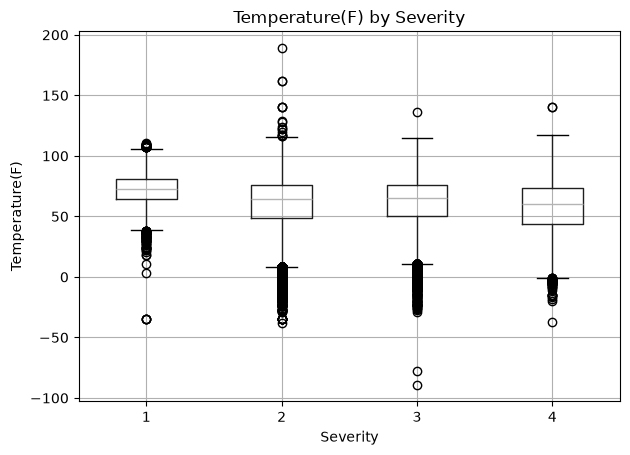

<Figure size 900x600 with 0 Axes>

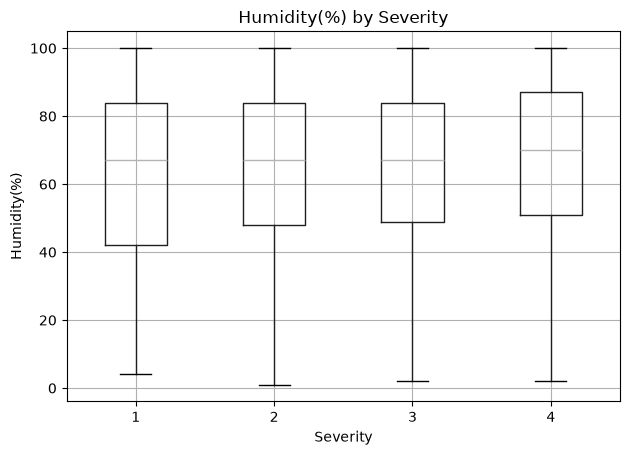

<Figure size 900x600 with 0 Axes>

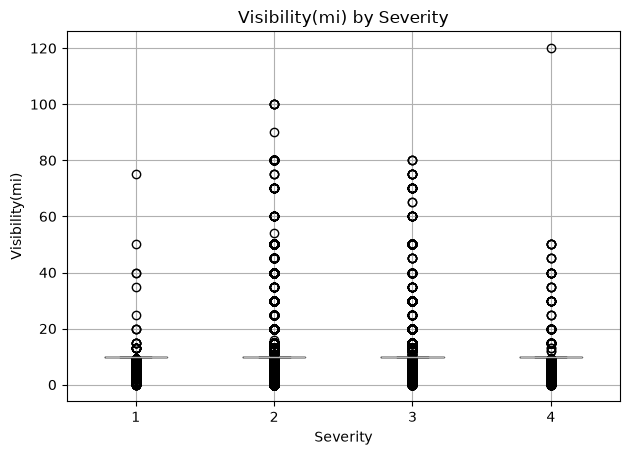

<Figure size 900x600 with 0 Axes>

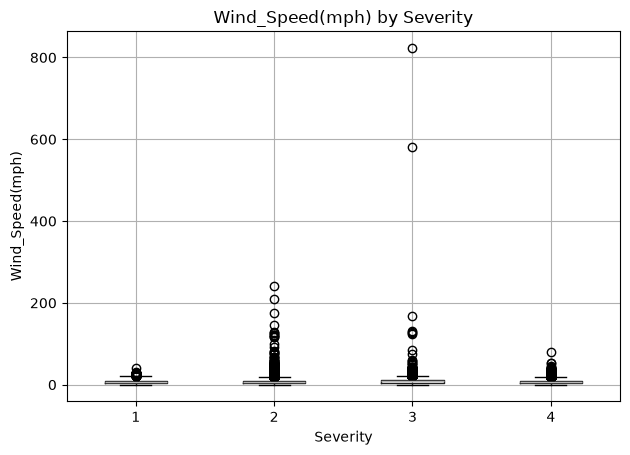

<Figure size 900x600 with 0 Axes>

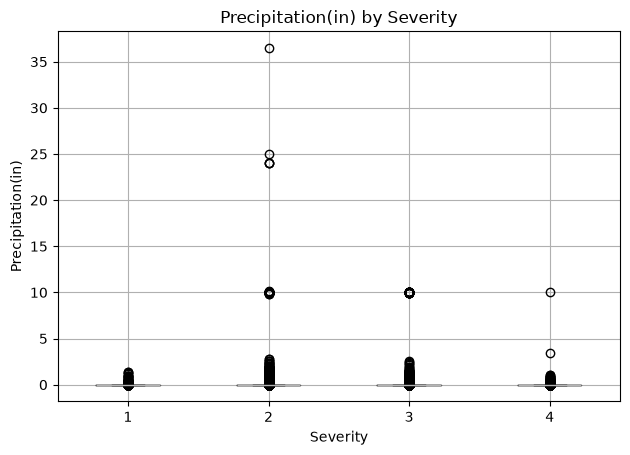

In [48]:
weather_features = ["Temperature(F)", "Humidity(%)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]

weather_summary = df.groupby("Severity")[weather_features].agg(["mean", "median"])
weather_summary.to_csv(f"{REPORT_DIR}/weather_by_severity.csv")

for feature in weather_features:
    plt.figure(figsize=(9, 6))
    df.boxplot(column=feature, by="Severity")
    plt.title(f"{feature} by Severity")
    plt.suptitle("")
    plt.xlabel("Severity")
    plt.ylabel(feature)
    plt.tight_layout()

    safe_name = feature.replace("(", "").replace(")", "").replace("/", "_").replace(" ", "_")

    plt.savefig(f"{FIGURE_DIR}/weather_{safe_name}_by_severity.png", dpi=300)
    plt.show()

### D.7 Severity distribution by state (top 15 by accident count)

<Figure size 1200x700 with 0 Axes>

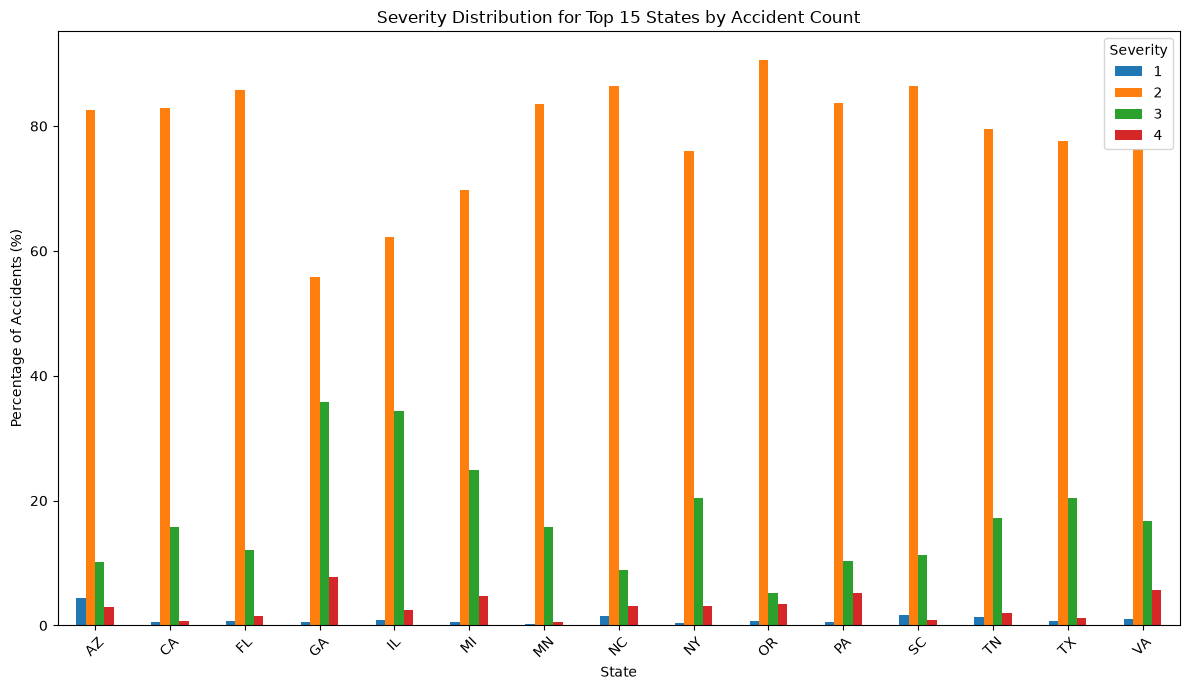

In [49]:
state_severity = pd.crosstab(df["State"], df["Severity"], normalize="index") * 100
state_severity = state_severity.round(2)
state_severity.to_csv(f"{REPORT_DIR}/state_severity_percentages.csv")

top_states = df["State"].value_counts().head(15).index
state_plot = state_severity.loc[state_severity.index.intersection(top_states)]

plt.figure(figsize=(12, 7))
state_plot.plot(kind="bar", figsize=(12, 7))
plt.title("Severity Distribution for Top 15 States by Accident Count")
plt.xlabel("State")
plt.ylabel("Percentage of Accidents (%)")
plt.xticks(rotation=45)
plt.legend(title="Severity")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/06_state_severity.png", dpi=300)
plt.show()

### D.8 Summary of generated outputs

In [50]:
print("\nEDA visualization completed successfully.")

print("\nGenerated figures:")
for file in sorted(os.listdir(FIGURE_DIR)):
    print(" -", file)

print("\nGenerated reports:")
for file in sorted(os.listdir(REPORT_DIR)):
    print(" -", file)

print("\nKey EDA areas completed:")
print("1. Severity distribution")
print("2. Missing-value analysis")
print("3. Year × Severity analysis")
print("4. Within-year severity percentages")
print("5. Missingness by severity")
print("6. Weather × Severity analysis")
print("7. State × Severity analysis")


EDA visualization completed successfully.

Generated figures:
 - 01_severity_distribution.png
 - 02_missing_values.png
 - 03_year_severity_counts.png
 - 04_year_severity_percentages.png
 - 05_missingness_by_severity.png
 - 06_state_severity.png
 - weather_Humidity%_by_severity.png
 - weather_Precipitationin_by_severity.png
 - weather_TemperatureF_by_severity.png
 - weather_Visibilitymi_by_severity.png
 - weather_Wind_Speedmph_by_severity.png

Generated reports:
 - categorical_encoding_results.csv
 - categorical_feature_analysis.csv
 - column_profile.csv
 - constant_columns.csv
 - duplicate_analysis.csv
 - feature_audit.csv
 - final_feature_selection.csv
 - invalid_value_summary.csv
 - invalid_value_treatment_results.csv
 - leakage_analysis.csv
 - missing_value_treatment_plan.csv
 - missing_value_treatment_results.csv
 - missing_values.csv
 - missingness_by_severity.csv
 - numeric_summary.csv
 - numerical_correlation_with_severity.csv
 - numerical_feature_analysis.csv
 - numerical_tran